In [1]:
#KAGGLE DATASET IS USED
#https://www.kaggle.com/datasets/anairamcosta/water-potability-csv
#'About Dataset
#Title: Water Potability Dataset
#
#Description:

#This dataset contains water quality metrics for various water bodies, indicating the potability (whether the water is safe for human consumption) of each sample. It provides a comprehensive overview of the chemical composition and physical properties of water, which are crucial factors in determining its suitability for drinking.

#Features:

#The dataset includes the following features, representing various water quality parameters:

#ph: pH of water (range: 0 to 14).
#Hardness: Measure of minerals in water.
#Solids: Total dissolved solids in ppm.
#Chloramines: Amount of chloramines in ppm.
#Sulfate: Amount of sulfates dissolved in water in ppm.
#Conductivity: Electrical conductivity of water in μS/cm.
#Organic_carbon: Amount of organic carbon in ppm.
#Trihalomethanes: Amount of trihalomethanes in μg/L.
#Turbidity: Measure of light1 scattering properties of water in NTU.
#Potability: Indicates if water is potable (1) or not (0).''


In [2]:
!git clone https://github.com/niaz1971/DRINKING_WATER_QUALITY_PREDICTION.git

Cloning into 'DRINKING_WATER_QUALITY_PREDICTION'...
remote: Enumerating objects: 10, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 10 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (10/10), 434.40 KiB | 11.14 MiB/s, done.


In [3]:
!ls

DRINKING_WATER_QUALITY_PREDICTION  sample_data


In [4]:
cd DRINKING_WATER_QUALITY_PREDICTION/

/content/DRINKING_WATER_QUALITY_PREDICTION


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# WATER POTABILITY PREDICTION — INTEGRATED ANN
# Features: Full EDA + Batch Normalization & Leaky ReLU (per Class Notes)
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, f1_score, accuracy_score)
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping

In [6]:
# ── Colour palette ───────────────────────────────────────────────────────────
C = dict(
    blue='#1E40AF', sky='#38BDF8', green='#059669', red='#DC2626',
    amber='#D97706', purple='#7C3AED', slate='#475569', light='#F1F5F9',
    mid='#CBD5E1', dark='#0F172A', white='#FFFFFF',
    accent1='#0EA5E9', accent2='#10B981', accent3='#F59E0B', accent4='#EF4444'
)

def section_banner(title):
    print(f"\n{'─'*60}")
    print(f"  {title}")
    print(f"{'─'*60}")

In [7]:
!ls

image_0.png  not_drinking_water.png  water_potability.csv


In [8]:
# 0. LOAD DATA
# ─────────────────────────────────────────────
section_banner("0. LOAD DATA")

df_raw = pd.read_csv('water_potability.csv')
print(f"  Raw shape: {df_raw.shape}")
print(f"  Columns  : {df_raw.columns.tolist()}")

# ─────────────────────────────────────────────
# 1. EDA
# ─────────────────────────────────────────────
section_banner("1. EXPLORATORY DATA ANALYSIS")

feat_cols = [c for c in df_raw.columns if c != 'Potability']
palette   = [C['blue'], C['green'], C['purple'], C['amber'], C['sky'],
             C['accent2'], C['accent3'], C['accent4'], C['red']]



────────────────────────────────────────────────────────────
  0. LOAD DATA
────────────────────────────────────────────────────────────
  Raw shape: (3276, 10)
  Columns  : ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability']

────────────────────────────────────────────────────────────
  1. EXPLORATORY DATA ANALYSIS
────────────────────────────────────────────────────────────


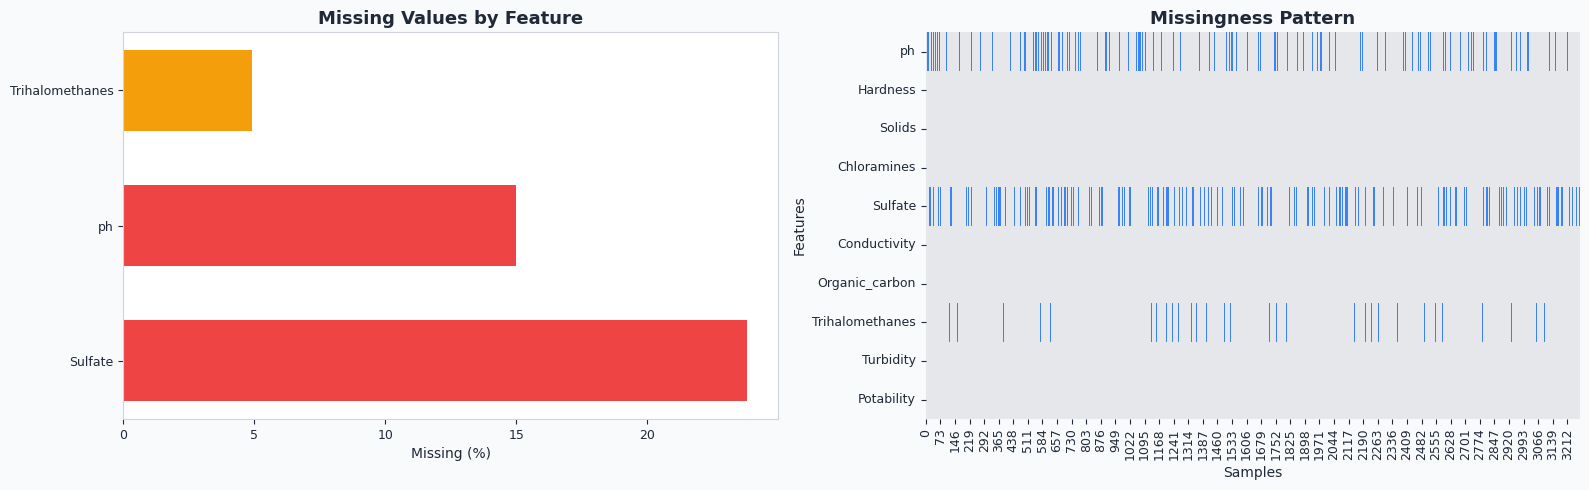

In [9]:
# Missing values summary
missing = df_raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df_raw) * 100).round(1)

# Simple new color scheme
BG = '#F8FAFC'
PANEL = '#FFFFFF'
TEXT = '#1F2937'
GRID = '#D1D5DB'
BLUE = '#3B82F6'
ORANGE = '#F59E0B'
RED = '#EF4444'
TEAL = '#14B8A6'

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor(BG)

for ax in axes:
    ax.set_facecolor(PANEL)
    ax.tick_params(colors=TEXT, labelsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID)

# Bar chart
colors_bar = [RED if v > 10 else ORANGE for v in missing_pct]
axes[0].barh(missing.index, missing_pct.values, color=colors_bar, height=0.6)
axes[0].set_title('Missing Values by Feature', color=TEXT, fontsize=13, fontweight='bold')
axes[0].set_xlabel('Missing (%)', color=TEXT)

# Heatmap
sns.heatmap(
    df_raw.isnull().T,
    ax=axes[1],
    cmap=['#E5E7EB', BLUE],
    cbar=False
)
axes[1].set_title('Missingness Pattern', color=TEXT, fontsize=13, fontweight='bold')
axes[1].set_xlabel('Samples', color=TEXT)
axes[1].set_ylabel('Features', color=TEXT)

plt.tight_layout()
plt.show()

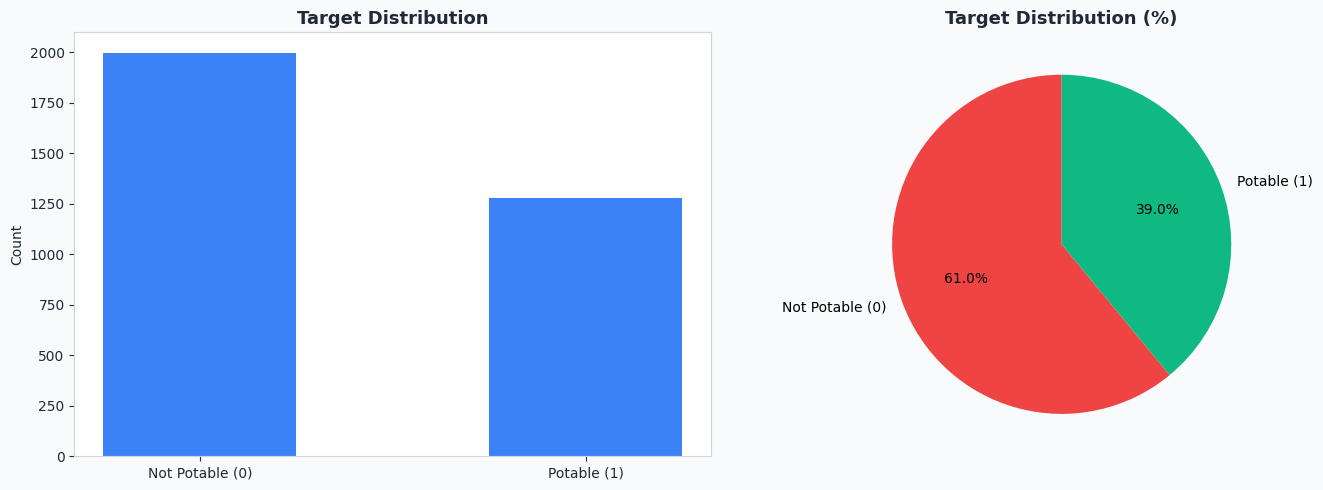

In [10]:
# Target distribution
counts = df_raw['Potability'].value_counts()
labels = ['Not Potable (0)', 'Potable (1)']

# Simple new colors
BAR_COLOR = '#3B82F6'     # blue
PIE_COLOR1 = '#EF4444'    # red
PIE_COLOR2 = '#10B981'    # green
BG = '#F8FAFC'
PANEL = '#FFFFFF'
TEXT = '#1F2937'
GRID = '#D1D5DB'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(BG)

for ax in axes:
    ax.set_facecolor(PANEL)
    ax.tick_params(colors=TEXT)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID)

# Bar chart
axes[0].bar(labels, counts.values, color=BAR_COLOR, width=0.5)
axes[0].set_title('Target Distribution', color=TEXT, fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count', color=TEXT)

# Pie chart
axes[1].pie(
    counts.values,
    labels=labels,
    colors=[PIE_COLOR1, PIE_COLOR2],
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Target Distribution (%)', color=TEXT, fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

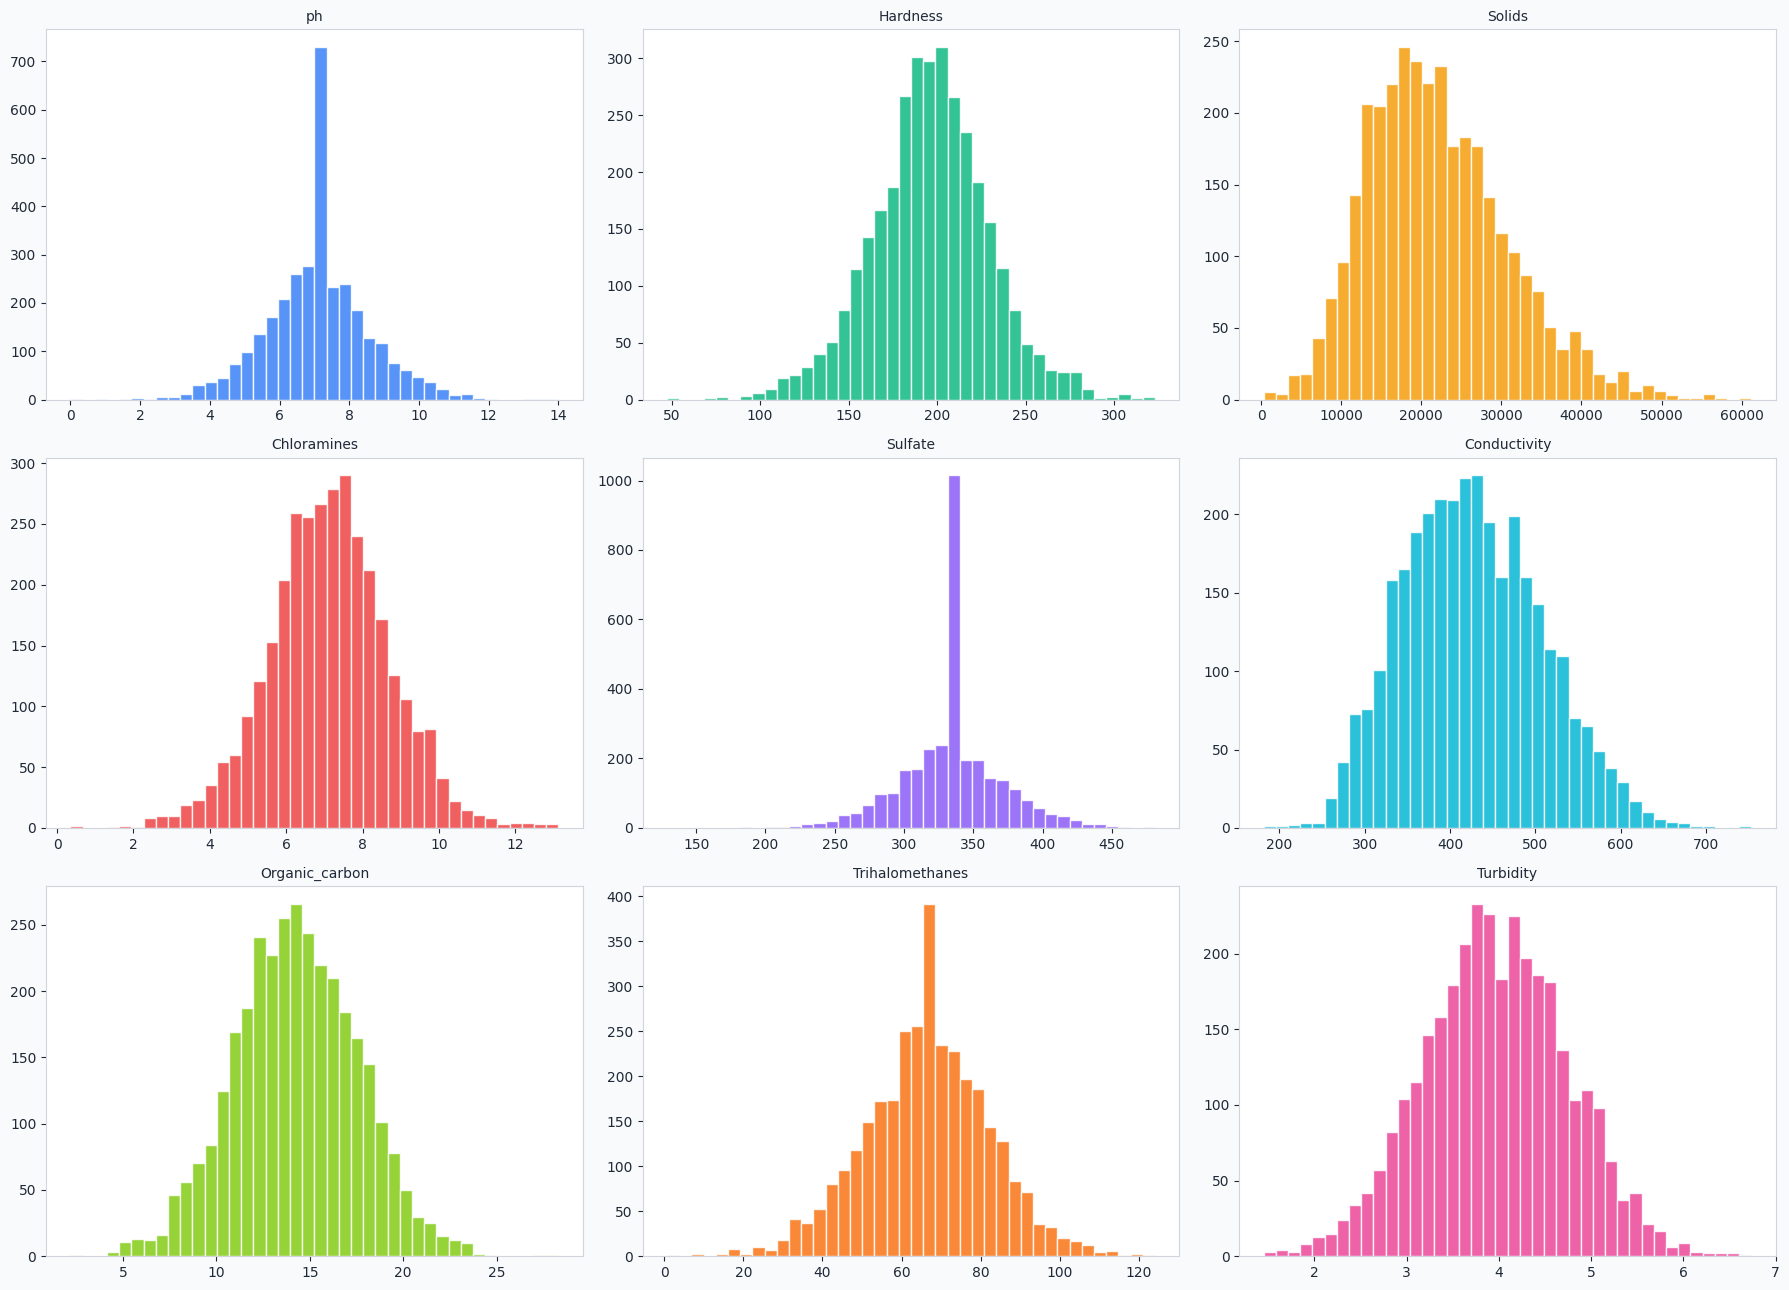

In [11]:
# Feature distributions
df_temp = df_raw.copy()
df_temp[feat_cols] = df_temp[feat_cols].fillna(df_temp[feat_cols].median())

# Simple new color scheme
BG = '#F8FAFC'
PANEL = '#FFFFFF'
TEXT = '#1F2937'
GRID = '#D1D5DB'
COLORS = ['#3B82F6', '#10B981', '#F59E0B', '#EF4444', '#8B5CF6',
          '#06B6D4', '#84CC16', '#F97316', '#EC4899']

fig, axes = plt.subplots(3, 3, figsize=(18, 13))
fig.patch.set_facecolor(BG)

for i, col in enumerate(feat_cols):
    ax = axes.flatten()[i]
    ax.set_facecolor(PANEL)
    ax.hist(df_temp[col], bins=40, color=COLORS[i % len(COLORS)], alpha=0.85, edgecolor='white')
    ax.set_title(col, color=TEXT, fontsize=10)
    ax.tick_params(colors=TEXT)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID)

plt.tight_layout()
plt.show()

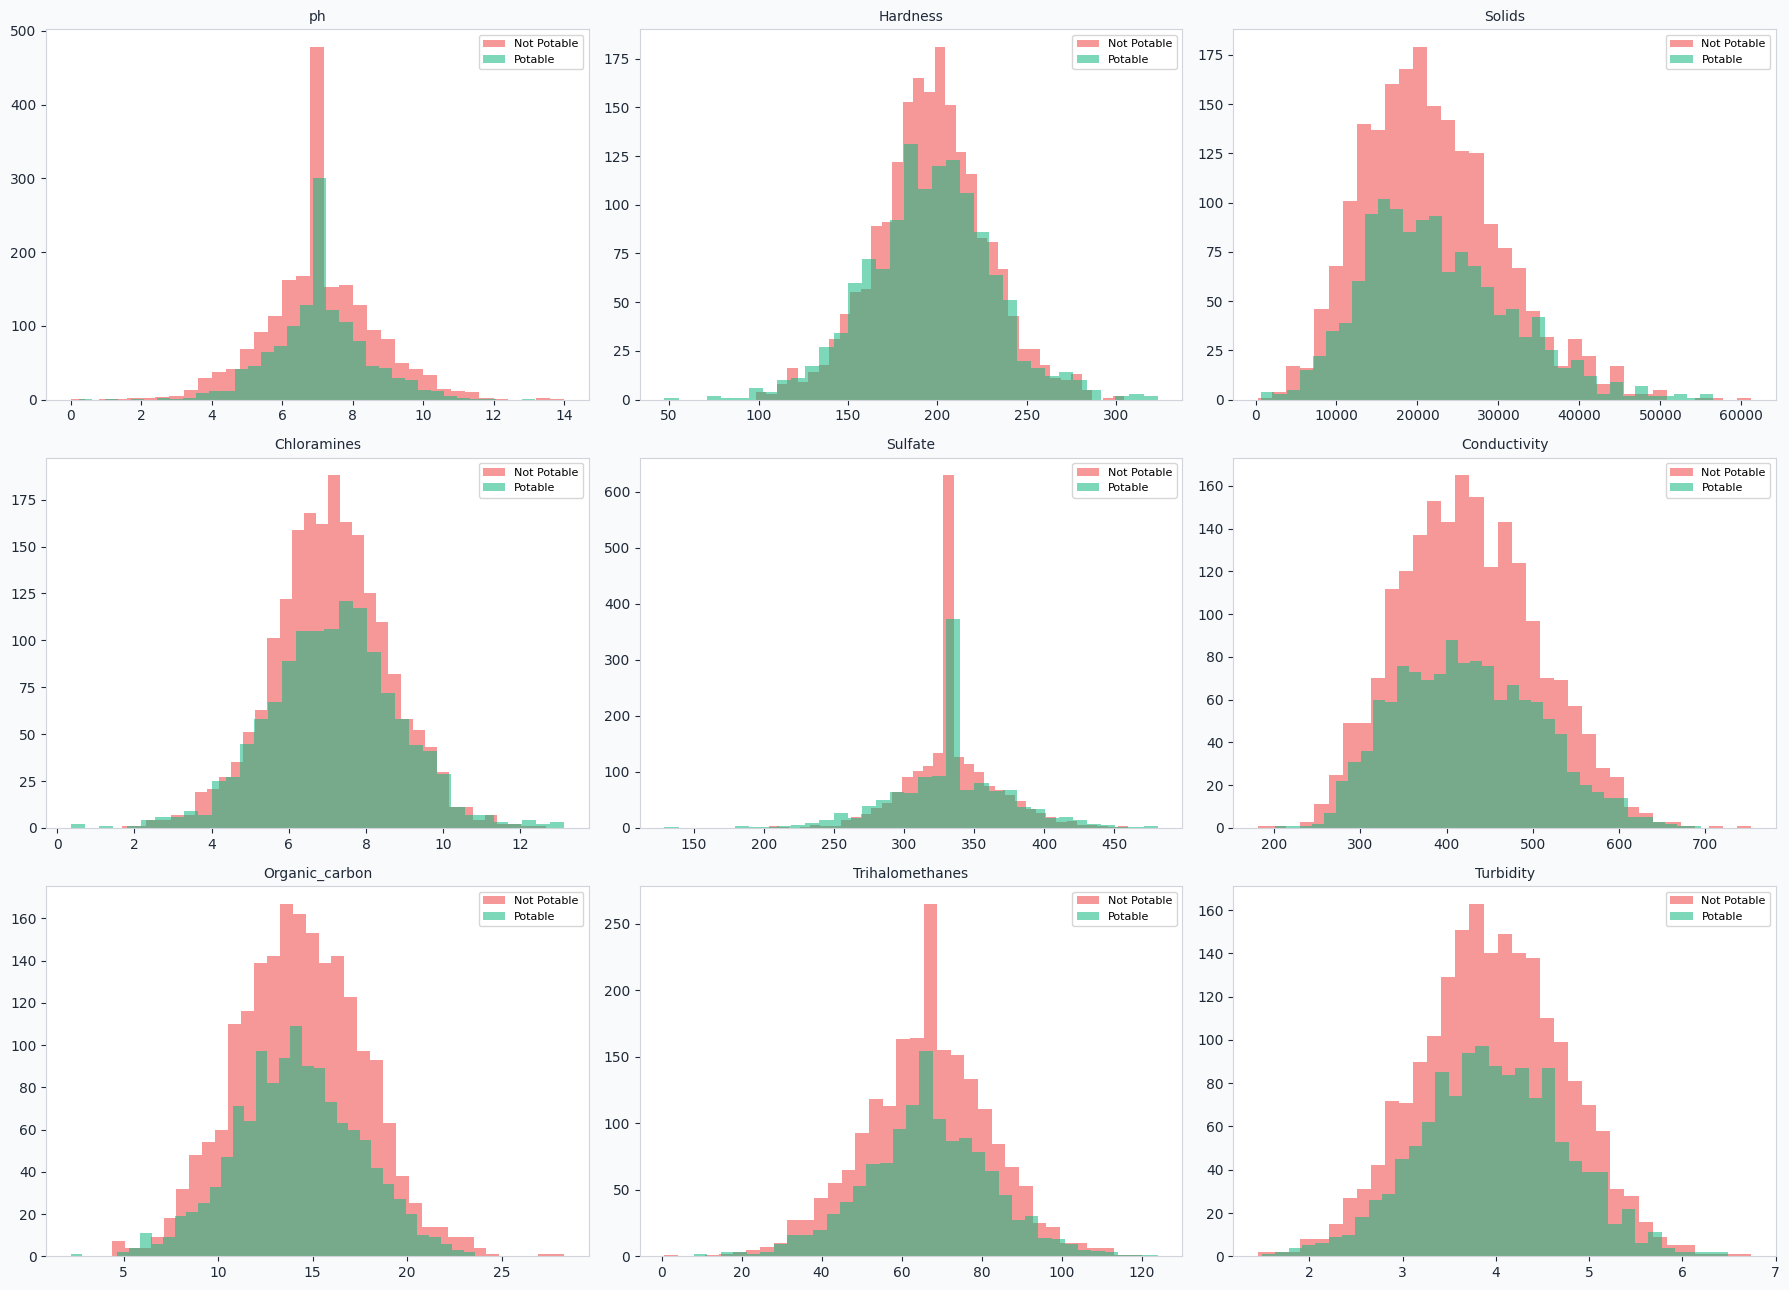

In [12]:
# Feature distributions by class
fig, axes = plt.subplots(3, 3, figsize=(18, 13))
fig.patch.set_facecolor('#F8FAFC')

# Simple colors
BG = '#F8FAFC'
PANEL = '#FFFFFF'
TEXT = '#1F2937'
GRID = '#D1D5DB'
NOT_POTABLE = '#EF4444'
POTABLE = '#10B981'

for i, col in enumerate(feat_cols):
    ax = axes.flatten()[i]
    ax.set_facecolor(PANEL)

    ax.hist(
        df_temp[df_temp['Potability'] == 0][col],
        bins=35,
        color=NOT_POTABLE,
        alpha=0.55,
        label='Not Potable'
    )

    ax.hist(
        df_temp[df_temp['Potability'] == 1][col],
        bins=35,
        color=POTABLE,
        alpha=0.55,
        label='Potable'
    )

    ax.set_title(col, color=TEXT, fontsize=10)
    ax.tick_params(colors=TEXT)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID)

    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

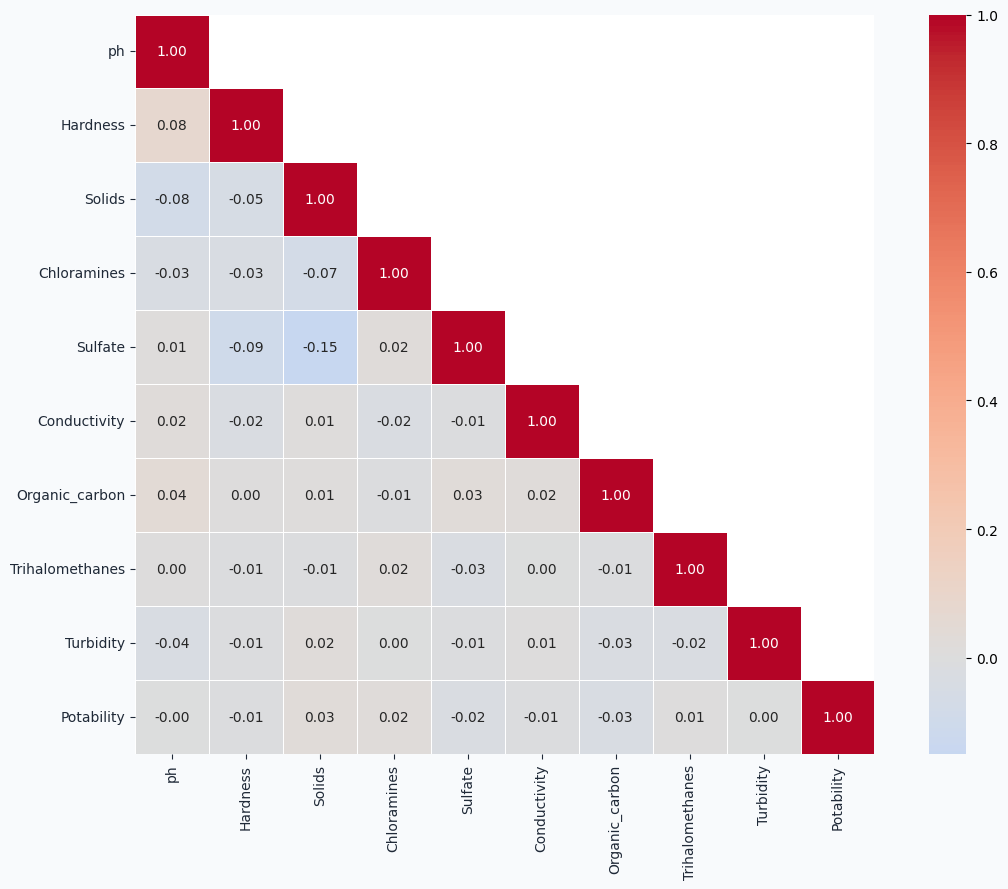

In [13]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(12, 9))
fig.patch.set_facecolor('#F8FAFC')

corr = df_temp.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(
    corr,
    mask=mask,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    square=True,
    ax=ax
)

ax.set_facecolor('#FFFFFF')
ax.tick_params(colors='#1F2937')
plt.tight_layout()
plt.show()

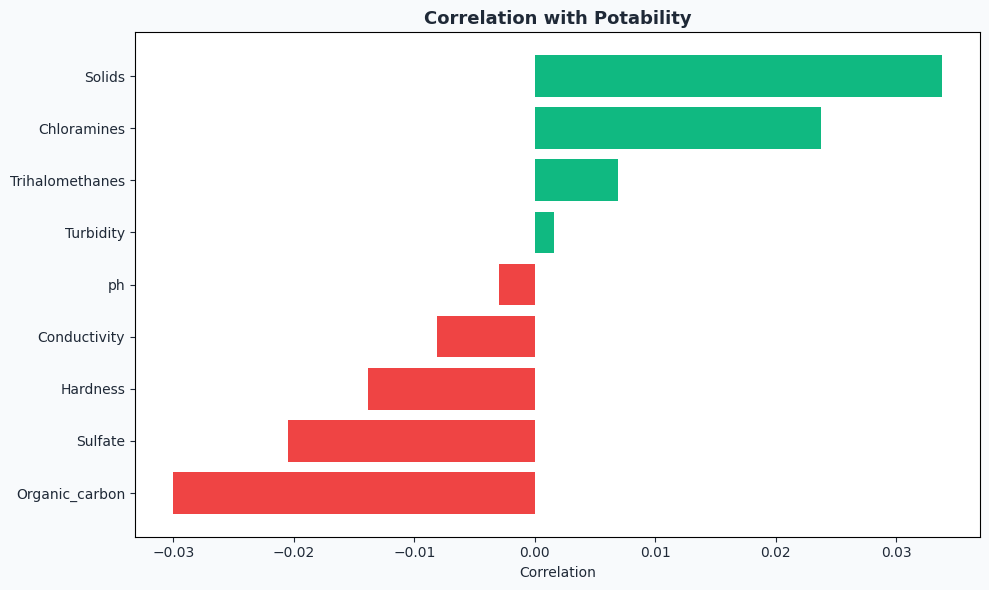

In [14]:
# Feature correlation with target
target_corr = corr['Potability'].drop('Potability').sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#F8FAFC')

colors = ['#EF4444' if v < 0 else '#10B981' for v in target_corr.values]

ax.barh(target_corr.index, target_corr.values, color=colors)
ax.set_facecolor('#FFFFFF')
ax.tick_params(colors='#1F2937')
ax.set_title('Correlation with Potability', color='#1F2937', fontsize=13, fontweight='bold')
ax.set_xlabel('Correlation', color='#1F2937')

plt.tight_layout()
plt.show()

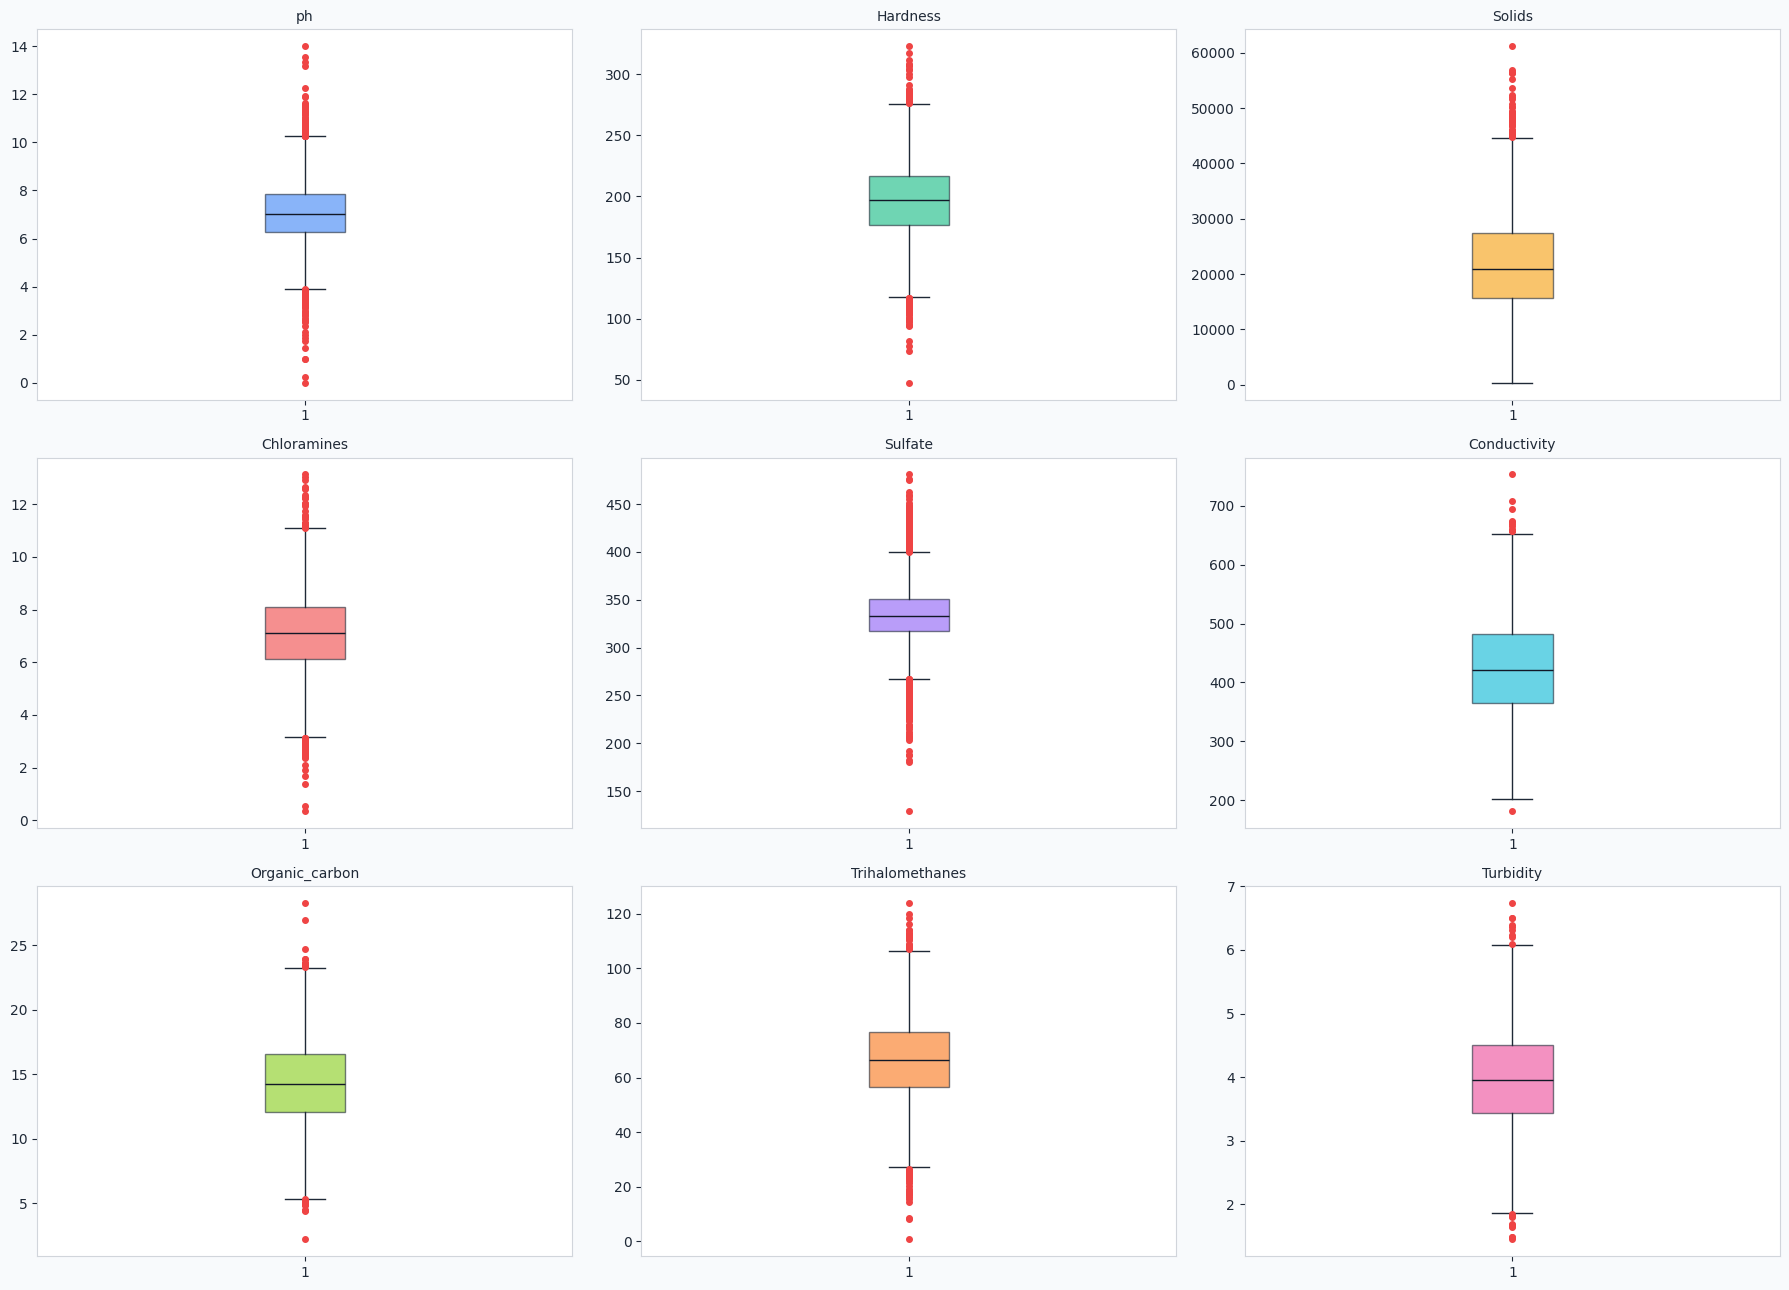

In [15]:
# Outlier analysis
fig, axes = plt.subplots(3, 3, figsize=(18, 13))
fig.patch.set_facecolor('#F8FAFC')

BG = '#F8FAFC'
PANEL = '#FFFFFF'
TEXT = '#1F2937'
GRID = '#D1D5DB'
COLORS = ['#3B82F6', '#10B981', '#F59E0B', '#EF4444', '#8B5CF6',
          '#06B6D4', '#84CC16', '#F97316', '#EC4899']

for i, col in enumerate(feat_cols):
    ax = axes.flatten()[i]
    ax.set_facecolor(PANEL)

    bp = ax.boxplot(
        df_temp[col],
        patch_artist=True,
        boxprops=dict(facecolor=COLORS[i % len(COLORS)], edgecolor=TEXT, alpha=0.6),
        whiskerprops=dict(color=TEXT),
        capprops=dict(color=TEXT),
        medianprops=dict(color='#111827'),
        flierprops=dict(marker='o', markerfacecolor='#EF4444', markeredgecolor='#EF4444', markersize=4)
    )

    ax.set_title(col, color=TEXT, fontsize=10)
    ax.tick_params(colors=TEXT)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID)

plt.tight_layout()
plt.show()

In [16]:
# ─────────────────────────────────────────────
# 3. PREPROCESSING
# ─────────────────────────────────────────────
section_banner("3. PREPROCESSING")

df = df_raw.copy()
df[feat_cols] = df[feat_cols].fillna(df[feat_cols].median())

X = df[feat_cols].values
y = df['Potability'].values


────────────────────────────────────────────────────────────
  3. PREPROCESSING
────────────────────────────────────────────────────────────


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

class_weights_arr = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: class_weights_arr[0], 1: class_weights_arr[1]}

# ─────────────────────────────────────────────
# 4. BUILD ANN MODEL (UPDATED per Class Notes)
# ─────────────────────────────────────────────
section_banner("4. BUILD ANN MODEL")

tf.random.set_seed(42)


────────────────────────────────────────────────────────────
  4. BUILD ANN MODEL
────────────────────────────────────────────────────────────


In [18]:
model = Sequential([
    # Layer 1 [cite: 4]
    Dense(64, input_shape=(X_train_sc.shape[1],)),
    BatchNormalization(),          # Slide Deck 4 Optimization [cite: 4]
    LeakyReLU(alpha=0.01),         # Slide Deck 3/4 Activation [cite: 3, 4]
    Dropout(0.3),

    # Layer 2 [cite: 4]
    Dense(32),
    BatchNormalization(),
    LeakyReLU(alpha=0.01),
    Dropout(0.2),

    # Layer 3 [cite: 4]
    Dense(16),
    BatchNormalization(),
    LeakyReLU(alpha=0.01),

    Dense(1, activation='sigmoid')   # Binary Output [cite: 2]
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# ─────────────────────────────────────────────
# 5. TRAIN MODEL
# ─────────────────────────────────────────────
section_banner("5. TRAIN MODEL")

# Patience increased to 15 to allow Batch Norm to stabilize [cite: 4]
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)

history = model.fit(
    X_train_sc, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,713 (14.50 KB)

 Trainable params: 3,489 (13.63 KB)

 Non-trainable params: 224 (896.00 B)


────────────────────────────────────────────────────────────
  5. TRAIN MODEL
────────────────────────────────────────────────────────────
Epoch 1/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.4833 - loss: 0.7366 - val_accuracy: 0.5973 - val_loss: 0.6792
Epoch 2/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5315 - loss: 0.7023 - val_accuracy: 0.5802 - val_loss: 0.6722
Epoch 3/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5720 - loss: 0.6888 - val_accuracy: 0.5802 - val_loss: 0.6640
Epoch 4/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5821 - loss: 0.6762 - val_accuracy: 0.5954 - val_loss: 0.6592
Epoch 5/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6131 - loss: 0.6601 - val_accuracy: 0.6031 - val_loss: 0.6512
Epoch 6/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6145 - loss: 0.6604 - val_accuracy: 0.6202 - val_loss: 0.6478
Epoch 7/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6322 - loss: 0.6518 - val_accura

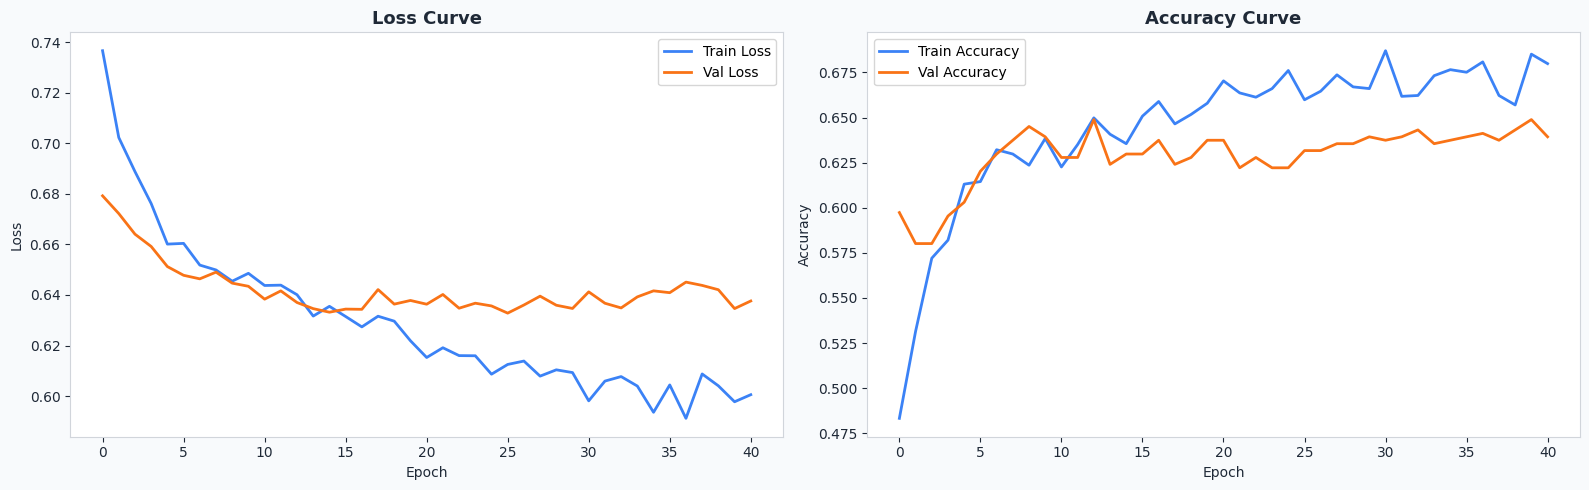

In [19]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#F8FAFC')

BG = '#F8FAFC'
PANEL = '#FFFFFF'
TEXT = '#1F2937'
GRID = '#D1D5DB'
TRAIN = '#3B82F6'
VALID = '#F97316'

for ax in axes:
    ax.set_facecolor(PANEL)
    ax.tick_params(colors=TEXT)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID)

axes[0].plot(history.history['loss'], color=TRAIN, label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], color=VALID, label='Val Loss', linewidth=2)
axes[0].set_title('Loss Curve', color=TEXT, fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch', color=TEXT)
axes[0].set_ylabel('Loss', color=TEXT)
axes[0].legend()

axes[1].plot(history.history['accuracy'], color=TRAIN, label='Train Accuracy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], color=VALID, label='Val Accuracy', linewidth=2)
axes[1].set_title('Accuracy Curve', color=TEXT, fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch', color=TEXT)
axes[1].set_ylabel('Accuracy', color=TEXT)
axes[1].legend()

plt.tight_layout()
plt.show()

In [20]:
# ─────────────────────────────────────────────
# 7. MODEL EVALUATION
# ─────────────────────────────────────────────
section_banner("7. MODEL EVALUATION")

y_prob = model.predict(X_test_sc).flatten()
y_pred = (y_prob >= 0.5).astype(int)


────────────────────────────────────────────────────────────
  7. MODEL EVALUATION
────────────────────────────────────────────────────────────
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


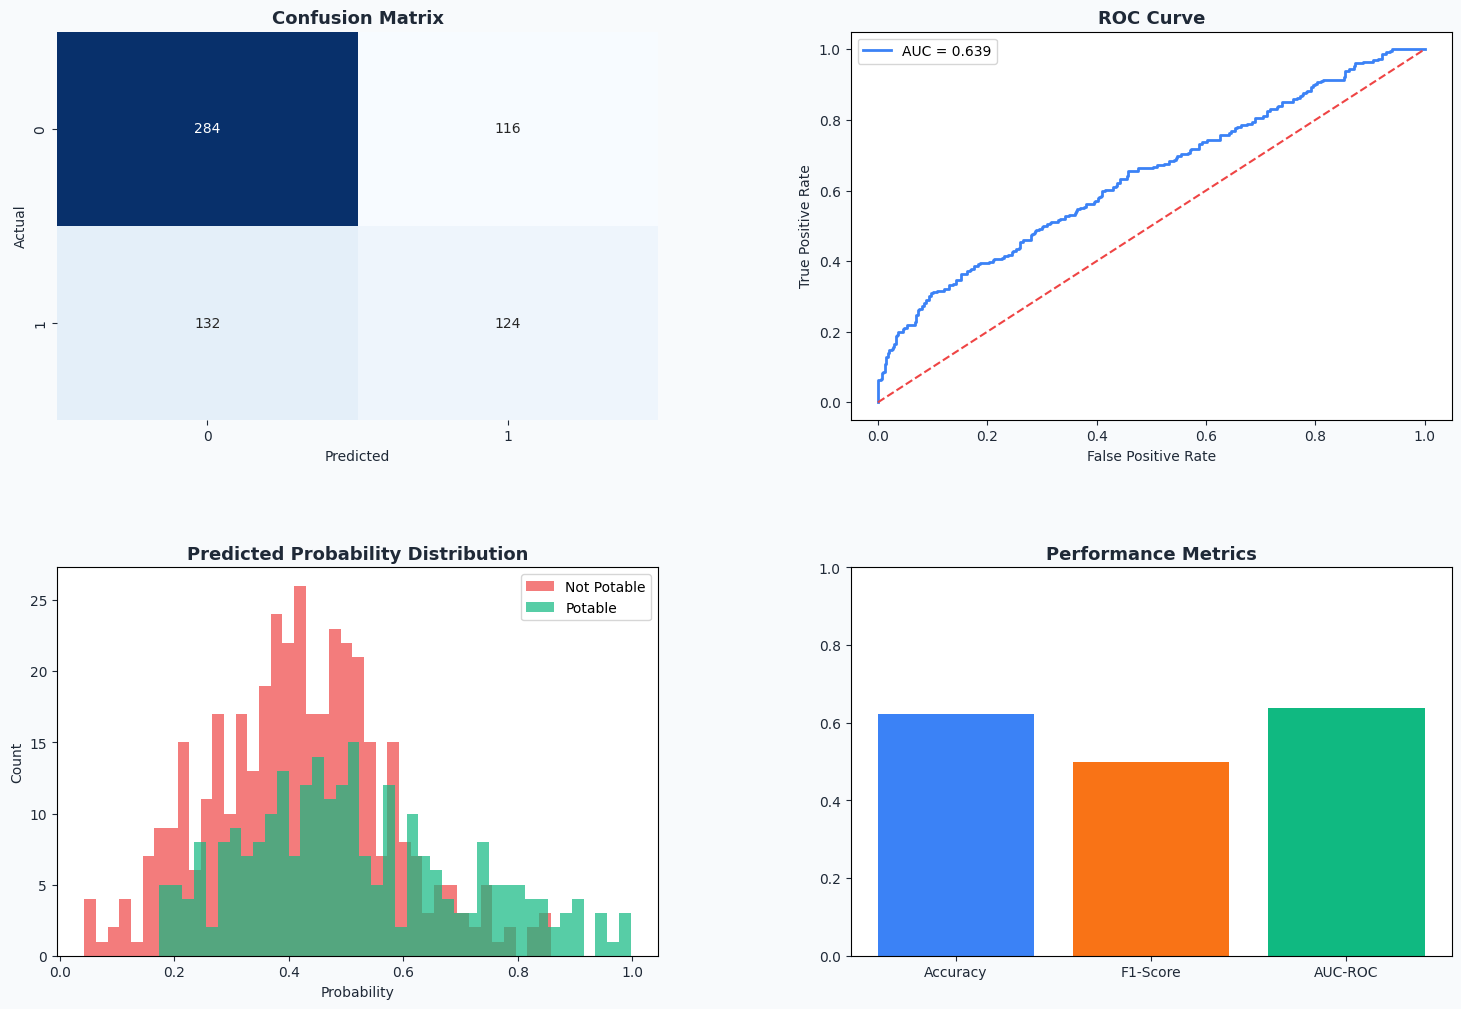

In [21]:
# Visual Evaluation Dashboard
fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor('#F8FAFC')
gs = gridspec.GridSpec(2, 2, hspace=0.38, wspace=0.32)

BG = '#F8FAFC'
PANEL = '#FFFFFF'
TEXT = '#1F2937'
GRID = '#D1D5DB'
BLUE = '#3B82F6'
ORANGE = '#F97316'
GREEN = '#10B981'
RED = '#EF4444'

# Confusion Matrix
ax_a = fig.add_subplot(gs[0, 0])
ax_a.set_facecolor(PANEL)
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax_a,
    cbar=False
)
ax_a.set_title('Confusion Matrix', color=TEXT, fontsize=13, fontweight='bold')
ax_a.set_xlabel('Predicted', color=TEXT)
ax_a.set_ylabel('Actual', color=TEXT)
ax_a.tick_params(colors=TEXT)

# ROC Curve
ax_b = fig.add_subplot(gs[0, 1])
ax_b.set_facecolor(PANEL)
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax_b.plot(fpr, tpr, color=BLUE, linewidth=2, label=f'AUC = {roc_auc_score(y_test, y_prob):.3f}')
ax_b.plot([0, 1], [0, 1], linestyle='--', color=RED, linewidth=1.5)
ax_b.set_title('ROC Curve', color=TEXT, fontsize=13, fontweight='bold')
ax_b.set_xlabel('False Positive Rate', color=TEXT)
ax_b.set_ylabel('True Positive Rate', color=TEXT)
ax_b.tick_params(colors=TEXT)
ax_b.legend()

# Probability Distribution
ax_c = fig.add_subplot(gs[1, 0])
ax_c.set_facecolor(PANEL)
ax_c.hist(y_prob[y_test == 0], bins=40, color=RED, alpha=0.7, label='Not Potable')
ax_c.hist(y_prob[y_test == 1], bins=40, color=GREEN, alpha=0.7, label='Potable')
ax_c.set_title('Predicted Probability Distribution', color=TEXT, fontsize=13, fontweight='bold')
ax_c.set_xlabel('Probability', color=TEXT)
ax_c.set_ylabel('Count', color=TEXT)
ax_c.tick_params(colors=TEXT)
ax_c.legend()

# Metrics Summary Bar
ax_d = fig.add_subplot(gs[1, 1])
ax_d.set_facecolor(PANEL)
metrics = [accuracy_score(y_test, y_pred), f1_score(y_test, y_pred), roc_auc_score(y_test, y_prob)]
labels = ['Accuracy', 'F1-Score', 'AUC-ROC']
ax_d.bar(labels, metrics, color=[BLUE, ORANGE, GREEN])
ax_d.set_ylim(0, 1)
ax_d.set_title('Performance Metrics', color=TEXT, fontsize=13, fontweight='bold')
ax_d.tick_params(colors=TEXT)

plt.tight_layout()
plt.show()


In [22]:
!ls

image_0.png  not_drinking_water.png  water_potability.csv


--- 💧 Water Potability Predictor ---
Enter pH: 7.275908774
Enter Hardness: 175.2203765
Enter Solids: 22644.76635
Enter Chloramines: 7.886854527
Enter Sulfate: 293.3098537
Enter Conductivity: 373.3456926
Enter Organic Carbon: 17.41168255
Enter Trihalomethanes: 56.79928677
Enter Turbidity: 5.062297798
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

✅ RESULT: POTABLE (SAFE TO DRINK)
Probability Score: 0.5534


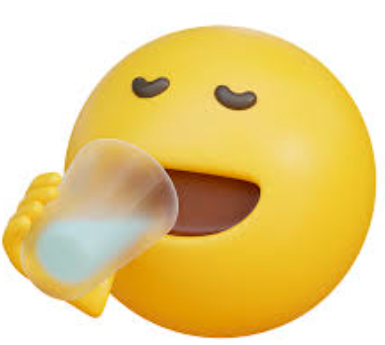

In [28]:
import numpy as np
from PIL import Image, ImageOps, ImageDraw
from IPython.display import display

# --- 1. SETUP IMAGES ---
try:
    # Your original happy drinking emoji
    safe_img = Image.open('image_0.png')

    # Check if you have a second specific image for "not safe"
    try:
        unsafe_img = Image.open('not_drinking_water.png')
    except FileNotFoundError:
        # If no second image, we create a "Warning" version of the first one
        unsafe_img = ImageOps.grayscale(safe_img).convert("RGB")
        draw = ImageDraw.Draw(unsafe_img)
        w, h = unsafe_img.size
        draw.line((0, 0, w, h), fill="red", width=20)
        draw.line((0, h, w, 0), fill="red", width=20)

except FileNotFoundError:
    print("⚠️ Please upload 'image_af04a7.png' to the Colab file folder.")
    safe_img = unsafe_img = None

# --- 2. USER INPUT SECTION ---
print("--- 💧 Water Potability Predictor ---")
try:
    # Collect all inputs first
    ph = float(input("Enter pH: "))
    hardness = float(input("Enter Hardness: "))
    solids = float(input("Enter Solids: "))
    chloramines = float(input("Enter Chloramines: "))
    sulfate = float(input("Enter Sulfate: "))
    conductivity = float(input("Enter Conductivity: "))
    organic_carbon = float(input("Enter Organic Carbon: "))
    trihalomethanes = float(input("Enter Trihalomethanes: "))
    turbidity = float(input("Enter Turbidity: "))

    # --- 3. MODEL PREDICTION ---
    sample = np.array([[ph, hardness, solids, chloramines, sulfate,
                       conductivity, organic_carbon, trihalomethanes, turbidity]])

    # Scale and Predict (ensure 'scaler' and 'model' are defined above this)
    sample_scaled = scaler.transform(sample)
    pred_prob = model.predict(sample_scaled)[0][0]

    # --- 4. DISPLAY RESULTS ---
    print("\n" + "="*40)

    if pred_prob >= 0.5:
        print(f"✅ RESULT: POTABLE (SAFE TO DRINK)")
        print(f"Probability Score: {pred_prob:.4f}")
        if safe_img:
            display(safe_img)
    else:
        print(f"❌ RESULT: NOT POTABLE (DANGER!)")
        print(f"Probability Score: {pred_prob:.4f}")
        if unsafe_img:
            display(unsafe_img)

    print("="*40)

except ValueError:
    print("⚠️ Input Error: Please enter numbers only.")
except Exception as e:
    print(f"⚠️ Error: {e}")

In [24]:
#7.275908774	175.2203765	22644.76635	7.886854527	293.3098537	373.3456926	17.41168255	56.79928677	5.062297798---->Drinkabal--->1

--- 💧 Water Potability Predictor ---
Enter pH: 6.5036382
Enter Hardness: 163.2566344
Enter Solids: 15000.18777
Enter Chloramines: 7.641833653
Enter Sulfate: 334.1031198
Enter Conductivity: 517.4283917
Enter Organic Carbon: 17.5306595
Enter Trihalomethanes: 37.76551768
Enter Turbidity: 4.963184434
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step

❌ RESULT: NOT POTABLE (DANGER!)
Probability Score: 0.3249


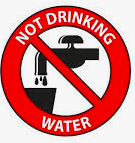

In [27]:
import numpy as np
from PIL import Image, ImageOps, ImageDraw
from IPython.display import display

# --- 1. SETUP IMAGES ---
try:
    # Your original happy drinking emoji
    safe_img = Image.open('image_0.png')

    # Check if you have a second specific image for "not safe"
    try:
        unsafe_img = Image.open('not_drinking_water.png')
    except FileNotFoundError:
        # If no second image, we create a "Warning" version of the first one
        unsafe_img = ImageOps.grayscale(safe_img).convert("RGB")
        draw = ImageDraw.Draw(unsafe_img)
        w, h = unsafe_img.size
        draw.line((0, 0, w, h), fill="red", width=20)
        draw.line((0, h, w, 0), fill="red", width=20)

except FileNotFoundError:
    print("⚠️ Please upload 'image_af04a7.png' to the Colab file folder.")
    safe_img = unsafe_img = None

# --- 2. USER INPUT SECTION ---
print("--- 💧 Water Potability Predictor ---")
try:
    # Collect all inputs first
    ph = float(input("Enter pH: "))
    hardness = float(input("Enter Hardness: "))
    solids = float(input("Enter Solids: "))
    chloramines = float(input("Enter Chloramines: "))
    sulfate = float(input("Enter Sulfate: "))
    conductivity = float(input("Enter Conductivity: "))
    organic_carbon = float(input("Enter Organic Carbon: "))
    trihalomethanes = float(input("Enter Trihalomethanes: "))
    turbidity = float(input("Enter Turbidity: "))

    # --- 3. MODEL PREDICTION ---
    sample = np.array([[ph, hardness, solids, chloramines, sulfate,
                       conductivity, organic_carbon, trihalomethanes, turbidity]])

    # Scale and Predict (ensure 'scaler' and 'model' are defined above this)
    sample_scaled = scaler.transform(sample)
    pred_prob = model.predict(sample_scaled)[0][0]

    # --- 4. DISPLAY RESULTS ---
    print("\n" + "="*40)

    if pred_prob >= 0.5:
        print(f"✅ RESULT: POTABLE (SAFE TO DRINK)")
        print(f"Probability Score: {pred_prob:.4f}")
        if safe_img:
            display(safe_img)
    else:
        print(f"❌ RESULT: NOT POTABLE (DANGER!)")
        print(f"Probability Score: {pred_prob:.4f}")
        if unsafe_img:
            display(unsafe_img)

    print("="*40)

except ValueError:
    print("⚠️ Input Error: Please enter numbers only.")
except Exception as e:
    print(f"⚠️ Error: {e}")

In [26]:
#6.5036382	163.2566344	15000.18777	7.641833653	334.1031198	517.4283917	17.5306595	37.76551768	4.963184434------>Not Drinkable-->	0